In [ ]:
!pip install phate scprep scanpy gdown pandas==2.2.0 

# Dimensionality reduction on the cancer dataset

Goals:
- Preprocess our raw single cell data
- Use the processed data to create a continuous latent space via PHATE.
- Understand how to interpret some of the PHATE parameters and how to choose a good representation of the space.

<a id='loading'></a>
## 1. Downloading the data

### Download the cancer data

Alternatively, you may load your own data by replacing the Google Drive file ids with your own file ids.

Note that if you do, you will likely not have sample labels. 
Replace all references to `'sample_labels'` with an entry from `adata.var_names`, or your favorite gene.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

%matplotlib inline

import phate
import scprep
import os
import gdown

In [ ]:
file_id = "1VCl5Gqpa-z99t9Ve0IP_ie_JVGbiYBN2"
url = f"https://drive.google.com/uc?id={file_id}"
output = "data.h5ad"
gdown.download(url, output, quiet=False)

In [ ]:
adata = sc.read_h5ad("data.h5ad")
adata

In [ ]:
data = pd.DataFrame(adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)
sample_labels = adata.obs['sample_labels']

<a id='preprocessing'></a>
## 2. Preprocessing: Filtering, Normalizing, and Transforming


We filter the data by: 
1. Filtering by library size (if we did not do this prior to combining batches)
2. Removing genes that are expressed in relatively few cells.
3. Removing dead cells

We filter dead cells after library size normalization, since library size is not necessarily related to cell state.

#### Filtering I. Library size filtering 

Library size is the total sum of gene counts in a cell.

We filter out cells that have either very large or very small library sizes. For this data set, library size correlates somewhat with sample and so we filter on a per-sample basis. In this case, we eliminate the top and bottom 20% of cells for each sample. Similar results are obtained with simpler, less conservative filtering.

<Axes: xlabel='Library size', ylabel='Number of cells'>

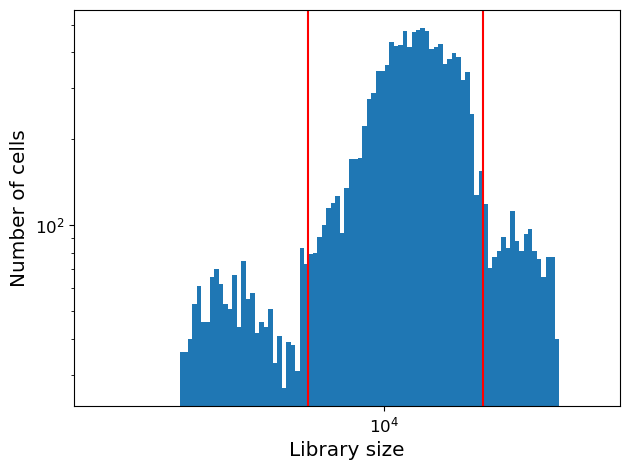

In [59]:
# Visualize the parts of the data we will drop.
# We will keep drop the bellow 20 and above 80 percentiles.
scprep.plot.plot_library_size(data, percentile=[10,90])

<a id='preprocessing'></a>
## 2. Preprocessing: Filtering, Normalizing, and Transforming

### Filtering

We filter the data by: 
1. Filtering by library size (if we did not do this prior to combining batches)
2. Removing genes that are expressed in relatively few cells.
3. Removing dead cells

We filter dead cells after library size normalization, since library size is not necessarily related to cell state.

In [ ]:
# Here you can change the percentile to remove more or less cell from processing
# Here we pass sample_labels so we can "drop" the sample labels as well.

data, sample_labels = scprep.filter.filter_library_size(data,sample_labels, percentile=10, keep_cells='above')
data, sample_labels = scprep.filter.filter_library_size(data,sample_labels, percentile=90, keep_cells='below')

### Filtering II. Remove rare genes

We eliminate genes that are expressed in 10 cells or fewer, they usually bring no information and increase the dimentionality of our data.

We are removing genes that appear in less than 10 cells.

In [62]:
data = scprep.filter.filter_rare_genes(data, min_cells=10)

### Normalization I. Library Size normalization

To correct for differences in library sizes, we divide each cell by its library size and then rescale by the median library size.

In python this is performed using the preprocessing method `library_size_normalize()`.

In [63]:
data = scprep.normalize.library_size_normalize(data)

#### Filtering III: Dead cell removal

Dead cells are likely to have a higher mitochondrial RNA expression level than live cells. Therefore, we remove suspected dead cells by eliminating cells that have the highest mitochondrial RNA expression levels on average.  

First let's look at the distribution of mitochontrial genes.

<Axes: xlabel='Gene expression', ylabel='Number of cells'>

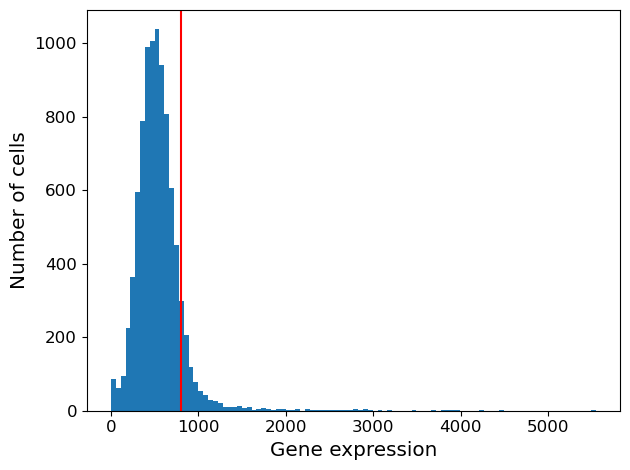

In [64]:
mito_genes = scprep.select.get_gene_set(data, starts_with="MT-") # Get all mitochondrial genes. There are 14, FYI.
scprep.plot.plot_gene_set_expression(data, genes=mito_genes, percentile=90)

Here we see that above the top 90th percentile, there is a steep increase in expression of mitochondrial RNAs. We'll remove these cells from further analysis.

In [66]:
data, sample_labels = scprep.filter.filter_gene_set_expression(
    data, sample_labels, genes=mito_genes, 
    percentile=90, keep_cells='below')

### Transformation I. Sqrt Transformation

In scRNA-seq analysis, the data is often $\log$-transformed. This typically requires the addition of some small value to avoid taking $\log(0)$. We avoid this issue entirely by instead taking the square root transform. The square root function has a similar form as the $\log$ function with the added benefit of being stable at 0.

In [67]:
data = scprep.transform.sqrt(data)

In [68]:
data

,A1BG (ENSG00000121410),A1BG-AS1 (ENSG00000268895),A2M-AS1 (ENSG00000245105),A4GALT (ENSG00000128274),AAAS (ENSG00000094914),AACS (ENSG00000081760),AADAT (ENSG00000109576),AAED1 (ENSG00000158122),AAGAB (ENSG00000103591),AAK1 (ENSG00000115977),...,ZW10 (ENSG00000086827),ZWILCH (ENSG00000174442),ZWINT (ENSG00000122952),ZXDA (ENSG00000198205),ZXDB (ENSG00000198455),ZXDC (ENSG00000070476),ZYG11A (ENSG00000203995),ZYG11B (ENSG00000162378),ZYX (ENSG00000159840),ZZEF1 (ENSG00000074755)
AAACCTGAGTTCGCGC-1_Day 0,1.246499,0.0,0.0,0.0,0.000000,0.000000,0.881408,0.881408,0.881408,1.246499,...,0.881408,0.881408,1.970888,0.0,0.0,0.0,0.0,0.0,0.881408,0.0
AAACCTGCAGGACCCT-1_Day 0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.893998,0.000000,0.000000,...,0.893998,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.893998,0.0
AAACCTGCATGTTGAC-1_Day 0,1.357751,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.357751,0.000000,0.960075,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1.357751,0.0
AAACCTGTCCTAGAAC-1_Day 0,0.000000,0.0,0.0,0.0,1.010823,0.000000,0.000000,1.010823,0.000000,0.000000,...,0.000000,0.000000,1.750797,0.0,0.0,0.0,0.0,0.0,1.429520,0.0
AAACCTGTCTACTATC-1_Day 0,1.499316,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.499316,0.0,0.0,0.0,0.0,0.0,1.836280,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCGCCACATCTTT-1_Day 30,0.000000,0.0,0.0,0.0,0.956905,0.000000,0.000000,0.000000,0.000000,0.956905,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.956905,0.0
TTTGCGCCAGTGGAGT-1_Day 30,0.000000,0.0,0.0,0.0,0.000000,0.830684,0.000000,0.000000,0.000000,1.174765,...,0.000000,0.000000,0.830684,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
TTTGCGCGTCTTGCGG-1_Day 30,1.362658,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
TTTGGTTAGATGTGGC-1_Day 30,1.016815,0.0,0.0,0.0,1.016815,0.000000,0.000000,0.000000,1.016815,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1.016815,0.0


## 3. Visualization using Principle Components Analysis (PCA)

Here we're going to use the simplest dimensionality reduction method first. We don't expect PCA to work well because the dataset is so complex, but it's a good place to start with any dataset.

#### Running PCA on the EB data

In [70]:
data_pca = scprep.reduce.pca(data, n_components=200, method='dense')

In [71]:
data_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC191,PC192,PC193,PC194,PC195,PC196,PC197,PC198,PC199,PC200
AAACCTGAGTTCGCGC-1_Day 0,-2.151234,-20.161300,-11.660890,0.250629,8.086731,-2.548236,3.421090,4.268757,-2.757228,3.108094,...,0.389738,0.222101,0.281117,0.118094,-0.154799,0.976849,0.827453,0.359140,0.278755,2.421396
AAACCTGCAGGACCCT-1_Day 0,-10.784692,-19.760689,-5.644786,0.459248,2.447105,-7.125523,0.787757,4.365165,0.860553,-4.728552,...,-0.602469,1.102013,-1.220901,-0.510541,-0.990329,-2.142788,-0.448124,0.501412,-0.387983,1.690358
AAACCTGCATGTTGAC-1_Day 0,7.434677,-18.875827,-0.490905,4.901251,9.381868,-13.251973,3.461727,0.848952,0.100118,1.873264,...,-0.351918,0.586238,-1.257862,-0.201440,0.775982,-0.033838,-0.335907,-1.094116,0.621722,-1.251821
AAACCTGTCCTAGAAC-1_Day 0,-3.721536,-21.221853,-6.025239,1.600581,0.739891,2.225551,-4.788199,-1.601045,9.000426,-7.181286,...,1.243029,-0.769496,2.026187,2.475181,0.234177,1.202015,1.338836,0.445956,0.793950,1.459086
AAACCTGTCTACTATC-1_Day 0,-4.207833,-20.457318,-3.248245,1.018686,4.951011,-1.945418,7.344940,2.903984,-3.608576,-0.974051,...,0.315872,-0.077865,1.521585,-0.098873,0.711195,-0.486249,1.736205,0.519894,0.151857,0.147783


#### Plotting PCs using `scprep.plot`

The scprep package has a number of handy plotting features that act as a wrapper to `matplotlib`. You should know how to use `matplotlib` for more complicated plotting, but you can make all the plots we need in this tutorial with some help from `scprep`.

The full documentaiton of `scprep.plot` can be found here:

https://scprep.readthedocs.io/en/stable/reference.html#module-scprep.plot

NameError: name 'data_pca' is not defined

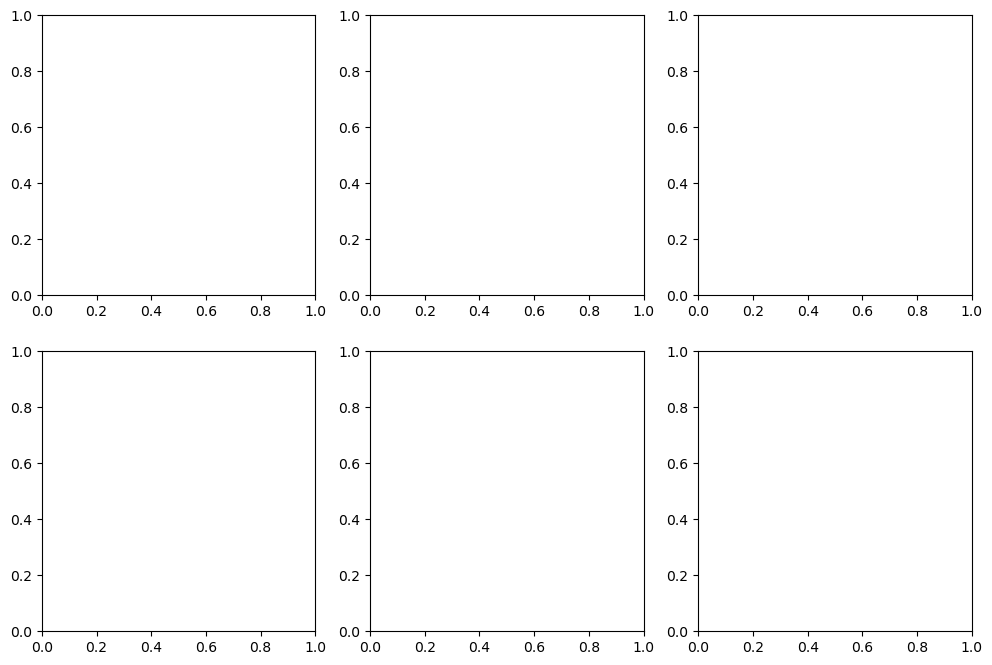

In [2]:
# Create a figure (the background) and a set of axes (the things we plot on)
fig, axes = plt.subplots(2,3, figsize=(12,8))
# This makes it easier to iterate through the axes
axes = axes.flatten()

for i, ax in enumerate(axes):
    # only plot a legend on one axis
    legend = True if i == 2 else False
    # There are a lot of parameters here, you can find the full scatter documentation at
    # https://scprep.readthedocs.io/en/stable/reference.html#scprep.plot.scatter
    scprep.plot.scatter(data_pca.iloc[:,i], data_pca.iloc[:,i+1], c=sample_labels,
                        cmap='Spectral', ax=ax,
                        label_prefix="PC", legend=legend)
fig.tight_layout()

#### Plotting expression of a gene on the first two PCs

Now let's plot expression of some genes!


In [3]:
gene = 'ZEB1'

expression = scprep.select.select_cols(data, exact_word=gene)

# we will sort cells by maximum expression so we can see where the gene is expressed
sort_index = expression.sort_values().index

scprep.plot.scatter2d(data_pca.loc[sort_index], c=expression.loc[sort_index], shuffle=False,
                     title=gene, ticks=None, label_prefix='PC')

NameError: name 'data' is not defined

In [4]:
gene = 'VIM'

# ================
# Sort cells by maximum expression of ACTB and plot the result on PCA
expression = scprep.select.select_cols(data, exact_word=gene)

sort_index = expression.sort_values().index

scprep.plot.scatter2d(data_pca.loc[sort_index], c=expression.loc[sort_index], shuffle=False,
                     title=gene, ticks=None, label_prefix='PC')
# ===============

NameError: name 'data' is not defined

In [5]:
gene = 'CDH1'

# ================
# Sort cells by maximum expression of HAND1 and plot the result on PCA
expression = scprep.select.select_cols(data, exact_word=gene)

sort_index = expression.sort_values().index

scprep.plot.scatter2d(data_pca.loc[sort_index], c=expression.loc[sort_index], shuffle=False,
                     title=gene, ticks=None, label_prefix='PC')
# ===============

NameError: name 'data' is not defined

### Discussion
# TODO: MODIFY DISCUSSION
1. What do you notice? What does the first principle component track with? What about the second? What do you think the higher PCs represent? What does that mean?

The first principal components tracks with sample time. The second expands as sample time increases, indicating some kind of cellular heterogeneity marker.

Higher PCs are likely to represent specific differences between cell types.

2. Why did we plot gene expression on the first two PCs?

The first two PCs represents the highest level structure of the data, so gene expression plotted on this gives us a broad understanding of what's happening in the data. The genes allows us to characterize each part of the manifold.

3. Look up the function of these genes. What do you notice about where these genes are expressed? What does it mean when a gene is expressed everywhere vs. in one region?

If a gene is expressed everywhere, it is likely some kind of housekeeping gene (indeed, Beta-actin is a part of the cell cytoskeleton and is expressed in all human cells.) If a gene is only expression in one region, it's likely to be cell-type specific, like HAND1 which is a heart / neural crest marker.

## 4. Embedding Data Using PHATE

#### How does PHATE work?

PHATE is a dimensionaltiy reduction developed by the Krishnaswamy lab for visualizing high-dimensional data. We use PHATE for *every* dataset the comes through the lab: scRNA-seq, CyTOF, gut microbiome profiles, simulated data, etc. PHATE was designed to handle noisy, non-linear relationships between data points. PHATE produces a low-dimensional representation that preserves both local and global structure in a dataset so that you can make generate hypotheses from the plot about the relationships between cells present in a dataset. Although PHATE has utility for analysis of many data modalities, we will focus on the application of PHATE for scRNA-seq analysis.

PHATE is inspired by diffusion maps [(Coifman et al. 2008.)](https://doi.org/10.1016/j.acha.2006.04.006), but include several key innovations that make it possible to generate a two or three dimensional visualization that preserves continuous relationships between cells where they exist. For a full explanation of the PHATE algorithm, please consult [the PHATE manuscript](https://doi.org/10.1101/120378).

#### Using the PHATE estimator

The API of PHATE models that of Scikit Learn. First, you instantiate a PHATE estimator object with the parameters for fitting the PHATE embedding to a given dataset. Next, you use the `fit` and `fit_transform` functions to generate an embedding. For more information, check out [**the PHATE readthedocs page**](http://phate.readthedocs.io/).

PHATE has it's own set of hyperparameters. Changing the parameters will greatly change the output of the algorithm. We reccomend starting with the defaults, then change `knn` and `decay` according the reccomendations below. Generally, we won't select `t` ourselves, but if you're tuning hyperparameters, it's best to fix `t`.

* `knn` : Number of nearest neighbors (default: 5). Increase this (e.g. to 20) if your PHATE embedding appears very disconnected. You should also consider increasing `k` if your dataset is extremely large (e.g. >100k cells)
* `decay` : Alpha decay (default: 15). Decreasing `a` increases connectivity on the graph, increasing `a` decreases connectivity. This rarely needs to be tuned. Set it to `None` for a k-nearest neighbors kernel.
* `t` : Number of times to power the operator (default: 'auto'). This is equivalent to the amount of smoothing done to the data. It is chosen automatically by default, but you can increase it if your embedding lacks structure, or decrease it if the structure looks too compact.
* `gamma` : Informational distance constant (default: 1). `gamma=1` gives the PHATE log potential, but other informational distances can be interesting. If most of the points seem concentrated in one section of the plot, you can try `gamma=0`.

Here's the simplest way to apply PHATE. Running this should take ~1-3 minutes.

In [89]:
phate_op = phate.PHATE(knn=5, n_jobs=-2)

data_phate = phate_op.fit_transform(data_pca.iloc[:,:50])
data_phate = pd.DataFrame(data_phate, index=data.index)

Calculating PHATE...
  Running PHATE on 8172 observations and 50 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 1.79 seconds.
    Calculating affinities...
    Calculated affinities in 0.04 seconds.
  Calculated graph and diffusion operator in 1.83 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.24 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.95 seconds.
  Calculated landmark operator in 2.74 seconds.
  Calculating optimal t...
    Automatically selected t = 22
  Calculated optimal t in 0.58 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.15 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 3.08 seconds.
Calculated PHATE in 8.39 seconds.


And then we plot using `scprep.plot.scatter2d`. For more advanced plotting, we recommend Matplotlib. If you want more help on using Matplotlib, they have [**extensive documentation**](https://matplotlib.org/tutorials/index.html) and [**many Stackoverflow threads**](https://stackoverflow.com/questions/tagged/matplotlib).

<Axes: xlabel='PHATE1', ylabel='PHATE2'>

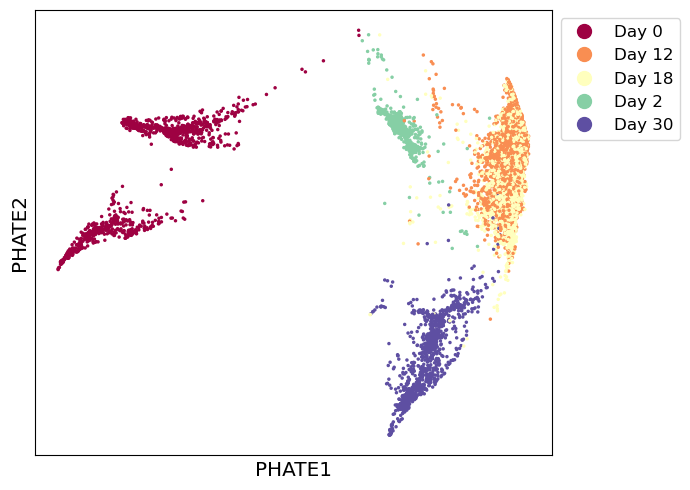

In [ ]:
# ================
# Plot the PHATE coordinates
# colored by time point
scprep.plot.scatter2d(data_phate, c=sample_labels, cmap='Spectral', 
                      ticks=False, label_prefix='PHATE',
                      legend_anchor=(1,1), figsize=(7,5))
# ================

#### Gene visualization

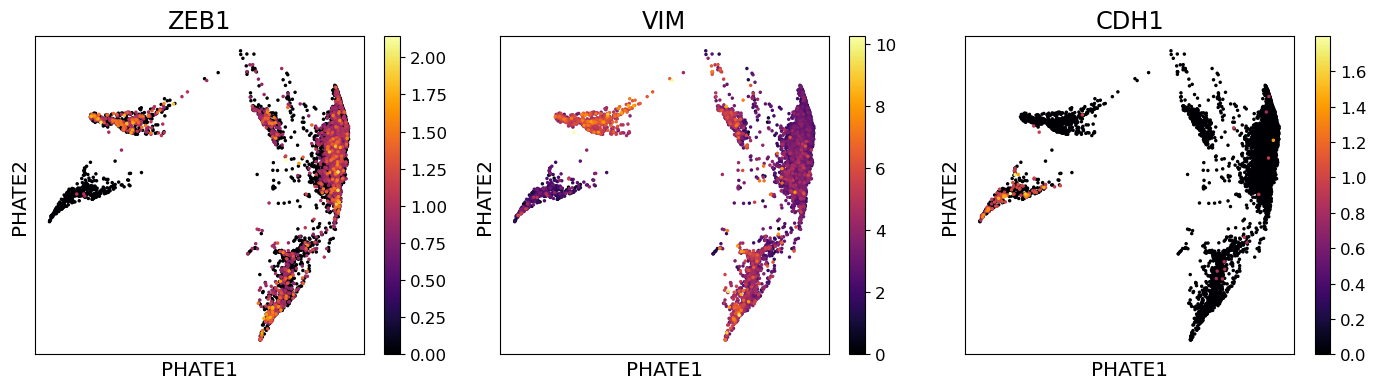

In [ ]:
# ================
# Plot three subplots of the PHATE coordinates
# coloring by ACTB, SOX10 and HAND1
genes_for_plotting = ['ZEB1','VIM','CDH1']

fig, axes = plt.subplots(1,3, figsize=(14,4))
axes = axes.flatten()

for gene, ax in zip(genes_for_plotting, axes.flatten()):
    expression = scprep.select.select_cols(data, exact_word=gene)
    
    sort_index = expression.sort_values().index
    
    scprep.plot.scatter2d(data_phate.loc[sort_index], c=expression.loc[sort_index], shuffle=False,
                         title=gene, ticks=None, label_prefix='PHATE', ax=ax)

fig.tight_layout()
# ================

### Discussion
# TODO:CREATE QUESTIONS
In groups, discuss the following questions:
1. In a dataset with trajectories, how well does each method perform?


2. Now that you've seen all the methods, how might you include them in a workflow?


3. What are the advantages of each method?


4. If you didn't know if your data contained clusters or trajectories, what would you do?
